# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 3</span>

### Exercise 03.1 <font color="red"> Plain vanilla option pricing </font>

Black-Scholes theory assumes that the time evolution of the asset price is stochastic and exhibits Geometric Brownian Motion (GBM) with constant risk-free interest rate $r$ and volatility $\sigma$.

Black-Scholes <u> analytic solution </u> for the price at time $t<T$:
                                                                     
- European Call-option price:
$$ C\left[ S(t),t \right] = S(t) N(d_1) -K e^{-r(T-t)} N(d_2) $$
- European Put-option price:
$$ P\left[ S(t),t \right] = S(t) \left[ N(d_1)-1\right] -K e^{-r(T-t)} \left[ N(d_2)-1\right]$$

where 
$$d_1 = \frac{1}{\sigma\sqrt{T-t}}\left[ \ln \left( \frac{S(t)}{K} \right) + \left( r+\frac{\sigma^2}{2} (T-t) \right)\right]$$

where $d_2 = d_1 - \sigma\sqrt{T-t}$, and where
$$ N(x) = \int_{-\infty}^{x} dz \, e^{-\frac{z^2}{2}} = \frac{1}{2} \left[ 1+ {\rm erf} \left( \frac{x}{\sqrt{2}}\right) \right]$$
is the cumulative of Gaussian $\sim \mathcal{N}(\mu=0,\sigma^2=1)$,
and where
$${\rm erf}(x) = \frac{2}{\sqrt{\pi}}\int_{0}^{x} dz \, e^{-z^2}$$

By using the following parameters:
- asset price at $t=0$: $S(0)=100$ 
- delivery time: $T=1$  
- strike price: $K=100$
- risk-free interest rate: $r=0.1$ (also denoted $\mu$) 
- volatility: $\sigma=0.25$  

Compute at time $t=0$ <strong>via Monte Carlo</strong> the European call-option price, $C[S(0),0]$, and put-option price, $P[S(0),0]$:

1. By sampling <span style="color:red"><strong>directly</strong></span> the final asset price $S(T)$ for a $GBM(r,\sigma^2)$
2. By sampling the discretized $GBM(r,\sigma^2)$ path of the asset price, dividing $[0,T]$ in $10^2$ time intervals: $S(0)$, $S(t_1)$, $S(t_2)$, ... up to $S(t_{100}=T=1)$

<p style="border:2px; border-style:solid; border-color:#F5F5F5; padding: 1em; background-color:#F5F5F5">
    Remember that given an asset price $S\sim GBM(\mu,\sigma^2)$, with initial value $S(0)$, then
    $$S(t) = S(0) \exp\left[ \left(\mu-\frac{1}{2}\sigma^2\right)t+\sigma W(t)\right]$$
    where $W(t)\sim\mathcal{N}(0,t)$.
    Moreover, since the increments of $W$ are independent and normally distributed, the simple recursive procedure for sampling discretized values of $S\sim GBM(\mu,\sigma^2)$ at $t_1 < t_2 < … < t_n$ is:
$$S(t_{i+1}) = S(t_i) \exp\left[ \left(\mu-\frac{1}{2}\sigma^2\right)(t_{i+1}-t_i)
    +\sigma Z_{i+1}\sqrt{t_{i+1}-t_i}\right]$$
    with $Z_i \sim \mathcal{N}(0,1)$
</p>

<span style="color:red">Make four pictures for the estimation of the European call-option prices, $C[S(0),0]$ (direct and discretized), and put-option prices, $P[S(0),0]$ (direct and discretized), with their uncertainties </span> with a large number of asset prices at time $t=T$, say $M\ge 10^4$, as a function of the number of blocks, $N$</font>. <span style="color:blue"> As usual, in computing statistical uncertainties, use data blocking.</span>

# Stochastic Calculus and Brownian Motion #

Brownian motion is a mathematical model for a path that changes in a continuous but completely unpredictable (random) way, hence introducing **randomness** in the system.

When dealing with stochastic (random) processes, operations like differentiation and integration can get complicated to perform. Typically, a stochastic motion presents "sharp edges" that cannot be differentiated. We then need a formalism to generalize calculus to Brownian Motion and Stochastic Motion.

## Wiener Process (a.k.a. Brownian Motion) ##

A Wiener process $\{W(t), t \geq 0\}$ is a continuous-time stochastic process with the following properties:

1. **Initial condition**:  
   $W(0) = 0$

2. **Independent increments**:  
   For any $0 \leq t_0 < t_1 < \cdots < t_n$, the increments  
   $$W(t_1) - W(t_0),\; W(t_2) - W(t_1),\; \dots,\; W(t_n) - W(t_{n-1})$$  
   are independent random variables.

3. **Stationary increments with normal distribution**:  
   For any $s < t$, the increment $W(t) - W(s)$ is normally distributed with mean $0$ and variance $t - s$:  
   $$W(t) - W(s) \sim \mathcal{N}(0, t - s)$$

4. **Continuous paths**:  
   The function $t \mapsto W(t)$ is continuous with probability 1 (almost surely).


## Sampling a Wiener Process ##

To sample a Wiener process (meaning to simulate numerically a Brownian motion) we approximate the continuous process by sampling values at discrete time points with the following assumptions:

#### **Step 1: Define the time grid**

Divide the time interval $[0, T]$ into $N$ equal steps:

- Time step: $\Delta t = \frac{T}{N}$
- Time grid: $t_0 = 0,\; t_1 = \Delta t,\; t_2 = 2\Delta t,\; \dots,\; t_N = N\Delta t = T$

#### **Step 2: Initialize the process**

Set the initial condition:

$$
W(0) = 0
$$

#### **Step 3: Generate the increments**

For each time step $i = 1, 2, \dots, N$, generate a normally distributed random variable:

$$
Z_i \sim \mathcal{N}(0, 1)
$$

Then compute the Wiener process increment:

$$
W(t_i) = W(t_{i-1}) + \sqrt{\Delta t} \cdot Z_i
$$

#### **Step 4: Repeat and construct the path**

Repeat the above step to build the full sample path:

$$
W(t_0), W(t_1), W(t_2), \dots, W(t_N)
$$

This gives a discrete approximation of the continuous Wiener process.

> Note: As $N \to \infty$ and $\Delta t \to 0$, the discrete process converges to the true Wiener process.


## The Itô Stochastic Integral ##

Intuitively the Itô integral allows to carry out an integration when the integrand is a stochastic process. In that sense it differs from a Riemann or a Lebesgue integral.

Mathematically, we can think of the Itô integral as a **Riemann sum**, but with **random increments** driven by the Brownian motion $W(t)$:

$$
\int_0^T f(t) \, dW(t) \approx \sum_{i=0}^{n-1} f(t_i) \cdot \left( W(t_{i+1}) - W(t_i) \right)
$$

- We use the **left endpoint** value $f(t_i)$ at each step. This is known as the **Itô interpretation**, which ensures that the integrand $f(t)$ is **non-anticipative** (i.e., it doesn't depend on future values of $W(t)$).
- As the partition gets finer ($\Delta t \to 0$), this sum **converges in the mean square sense**.

This approach allows us to define integrals of random processes driven by Brownian motion, even though $W(t)$ is nowhere differentiable.


# European Options #

- A "call option" is a financial product that grants the owner (with no obligation) to right buy or sell a stock (or an asset, commodity, etc.) at a predetermined "strike price".

- A "European" call option grants this right in particular at an "expiry date".

## _Put_ vs. _Call_ options ##

A CALL options allows the owner to buy the option on the market. The PUT option grants to owner to sell the option on the market.

<u>**Example**</u>:

A trader buys an option for a stock from LSN Inc, listed on the Milan Stock Exchange, at the strike price of 50 €. The expiration date is 3 months from the day the trader buys the option. The premium for this option (the "cost" of the option) is 5 €. The current market price of LSN stock is 45 €.

- **Scenario 1: the stock goes up, making a profit**

  At the expiry date the stock from LSN sells now at 60 € on the market, the trader has the right to buy it at the strike price of 50 € thanks to his option. If he now sells this stock on the market he makes a gross profit of 60 € - 50€ = 10€. Since the premium on that option was 5 €, his **net profit** is 10 € - 5 € = 5€.

- **Scenario 2: the stock goes down, losing the premium**

  If instead at the expiry date the stock from LSN sells at 45 €, then the trader has no interest in using the option to buy the stock at 50 €, since it is already available on the market at a lower price. Then the option expires and the trader loses the 5 € premium.

## Predicting Stock Options Pricing Values ##

The **solution** to the Black-Scholes model is used to determine the **fair price** $C[S(t),t]$ or $P[S(t),t]$ for call and put options respectively using the following parameters:

- asset price at $ t = 0$: $ S(0) $
- delivery time: $ T $
- strike price: $ K $
- risk-free interest rate: $ r $
- volatility: $ \sigma $

It assumes the asset price $S(t)$ follows a **Geometric Brownian Motion**, wich value is given by the equation:

$$S(t) = S(0) \exp\left[ \left(\mu-\frac{1}{2}\sigma^2\right)t+\sigma W(t)\right]$$

where:

- $\mu$ is the expected return of the asset
- $\sigma$ is the volatility (randomness)
- $W(t)$ is the standard Brownian motion (random walk) 


# SIMULATING THE EXPECTED PAYOFF #

The objective of the exercise is to calculate the pricing of Put and Call options at time $t=0$ given the listed parameters and the terminal asset price $S(t)$ using two Monte Carlo techniques:

- Direct sampling of the final asset price $S(T)$ using the closed-form solution of Geometric Brownian Motion (GBM)
- Discretized sampling of the GBM path, by simulating the asset price evolution over time steps from $t=0$ to $t=T$

We are effectively estimating the option prices by computing the expected payoff at expiration $T=0$, requires simulating many possible values of the asset price $S(T)$, because $S(T)$ is random under the Black-Scholes model.

### Why do we need to sample?

We are trying to compute the **expected payoff** of a European option at maturity \( T \):

$$
\mathbb{E}[\text{Payoff}(S(T))] = \mathbb{E}[\max(S(T) - K, 0)] \quad \text{(for a call option)}
$$

This expectation is taken over all the possible future values of the asset price $ S(T) $, which is **random** under the Geometric Brownian Motion (GBM) model.

---

### Why not just solve it analytically?

Although we *do* have the **Black-Scholes formula**, which gives us a closed-form solution:

$$
C(0) = S(0)N(d_1) - K e^{-rT} N(d_2)
$$

this formula is **derived** from evaluating the expected payoff mathematically. However, **without it**, computing this expectation directly is very hard because:

- $ S(T) $ is **lognormally distributed** (since $ \log S(T) $ is normal)
- The function $ \max(S(T) - K, 0) $ is **nonlinear and non-smooth** (due to the kink at $ S(T) = K $)
- As a result, the integral required to compute $ \mathbb{E}[\max(S(T) - K, 0)] $ **doesn't have a simple closed-form solution**

---

### Monte Carlo to the rescue

Instead of solving the expectation analytically, we can **estimate it numerically** via **Monte Carlo simulation**:

1. <span style="color:red">Sample many possible outcomes of $S(T)$</span> using the GBM model.
2. For each outcome, compute the option's payoff (e.g., $ \max(S(T) - K, 0) $ for a call).
3. Take the average of those payoffs.
4. Discount the result back to present value using $ e^{-rT} $.

This gives a good approximation of the expected value, especially as the number of samples increases.

---


## DIRECT SAMPLING: Sampling the Asset Price directly from Black-Scholes ##

The final asset price $S(t)$ at the delivery time $T$ can be determined by direct sampling with: 

$$
S(t)\big|_{t=T} = S(0) \ \text{exp} \left[ (\mu- 0.5 \cdot \sigma^2)\ t + \sigma \cdot \text{rnd.Gauss} \right]
$$

where $rnd.Gauss$ is a function that draws a random variable from a Gaussian probability distribution and where:

- $S_0=100$ : Initial Asset Price
- $\mu = 0.1$ : Risk Free Interest Rate
- $\sigma = 0.25$ : Volatility
- $K=100$ : Strike Price
- $T = 1.0$ : Delivery Time

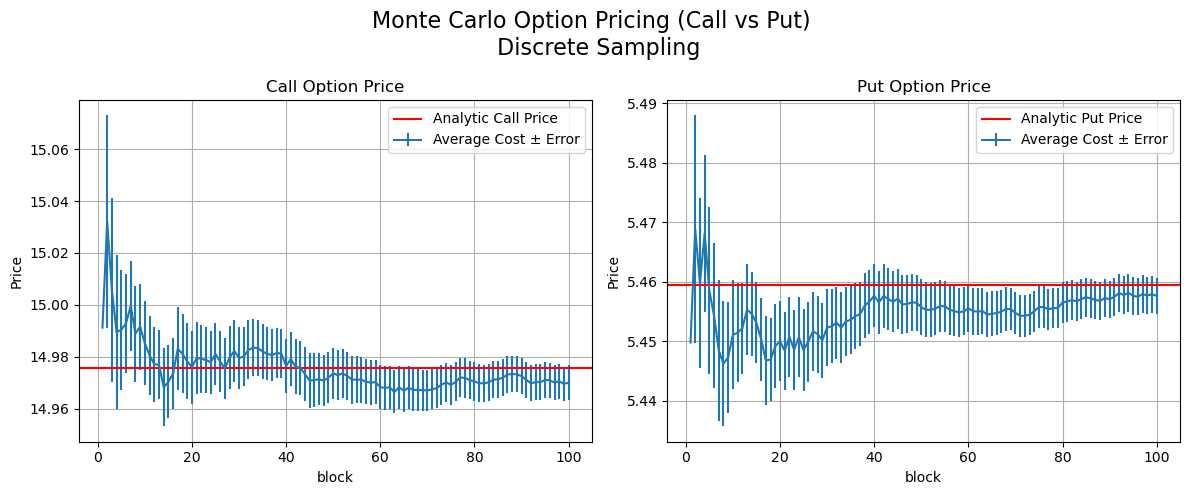

==== BLACK-SCHOLES ANALYTIC SOLUTIONS ====
Call fair price: 14.975790778311286
Put fair price: 5.4595325819072364


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import erf

# ====== Black-Scholes Analytic solution for later comparaison =======
# data
S0 = 100.
K = 100.
T = 1.
r = 0.1
sigma = 0.25
t=0

def N(x):
    return 0.5 * (1. + erf(x / np.sqrt(2.)))

def black_scholes(S0, K, T, r, sigma):
    d1 = 1./(sigma * np.sqrt(T)) * (np.log(S0 / K) + (r + (sigma**2) / 2.) * T)
    d2 = d1 - sigma * np.sqrt(T)
    C = S0 * N(d1) - K * np.exp(-r * T) * N(d2)
    P = S0 *(N(d1) - 1.) - K * np.exp(-r * T) * (N(d2)-1.)
    return C, P

if __name__ == "__main__":
    call, put = black_scholes(S0, K, T, r, sigma)

call_option_direct_sampling = np.loadtxt("./EX3_Parallel_Random_Generator/output_files/call_option_direct_sampling.dat",
                                         delimiter=",", skiprows=1)

put_option_direct_sampling = np.loadtxt("./EX3_Parallel_Random_Generator/output_files/put_option_direct_sampling.dat",
                                         delimiter=",", skiprows=1)

# Extract columns
call_avg = call_option_direct_sampling[:,0]
call_avg2 = call_option_direct_sampling[:,1]
call_error = call_option_direct_sampling[:,2]

put_avg = put_option_direct_sampling[:,0]
put_avg2 = put_option_direct_sampling[:,1]
put_error = put_option_direct_sampling[:,2]

# Create x-axis
x_call = np.arange(1, len(call_avg)+1)
x_put = np.arange(1, len(put_avg)+1)

# Create subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

axes[0].errorbar(x_call, call_avg, yerr=call_error, capsize=0, label="Average Cost ± Error")
axes[0].axhline(y=call, color='red', linestyle='-', label="Analytic Call Price")
axes[0].set_title("Call Option Price")
axes[0].set_xlabel("block")
axes[0].set_ylabel("Price")
axes[0].grid(True)
axes[0].legend()

axes[1].errorbar(x_put, put_avg, yerr=put_error, capsize=0, label="Average Cost ± Error")
axes[1].axhline(y=put, color='red', linestyle='-', label="Analytic Put Price")
axes[1].set_title("Put Option Price")
axes[1].set_xlabel("block")
axes[1].set_ylabel("Price")
axes[1].grid(True)
axes[1].legend()

fig.suptitle("Monte Carlo Option Pricing (Call vs Put) \n Discrete Sampling", fontsize=16)

plt.tight_layout()
plt.show()

print(f"==== BLACK-SCHOLES ANALYTIC SOLUTIONS ====")
print(f"Call fair price: {call}")
print(f"Put fair price: {put}")